In [1]:
#importing necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor
import lightgbm as lgb

from statsmodels.tsa.statespace.sarimax import SARIMAX

In [3]:
#loading dataset
df = pd.read_csv("../Data/EstateProductivityPrediction_dataset.csv")

In [4]:
#null/missing values
df['irradiance_SW_DWN']= df['irradiance_SW_DWN'].replace(-999, np.nan)   #sentinal value
df.isnull().sum()

year                   0
month                  0
month_num              0
wet_days               6
rainfall               6
male_workforce       105
female_workforce     105
temperature_T2M        0
irradiance_SW_DWN      1
yield                 19
dtype: int64

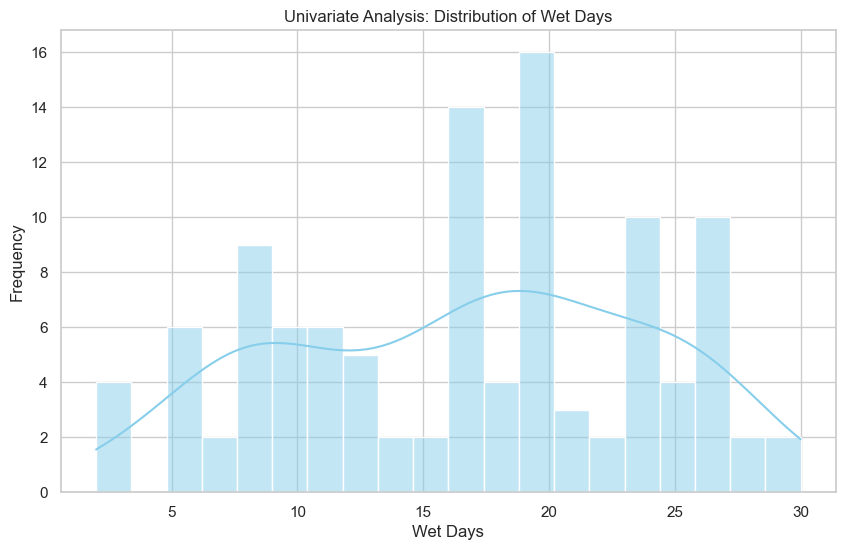

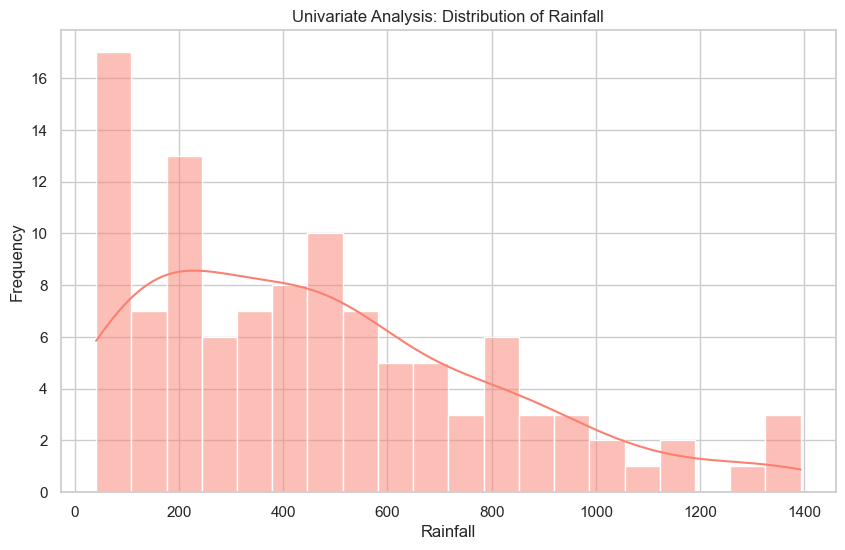

In [5]:
#Handling missing values

#plotting the features to understand better

#Set the visual style
sns.set_theme(style="whitegrid")

#Plot Histogram for 'wet_days'
plt.figure(figsize=(10, 6))
sns.histplot(df['wet_days'].dropna(), kde=True, color='skyblue', bins=20)
plt.title('Univariate Analysis: Distribution of Wet Days')
plt.xlabel('Wet Days')
plt.ylabel('Frequency')
plt.show()

#Plot Histogram for 'rainfall'
plt.figure(figsize=(10, 6))
sns.histplot(df['rainfall'].dropna(), kde=True, color='salmon', bins=20)
plt.title('Univariate Analysis: Distribution of Rainfall')
plt.xlabel('Rainfall')
plt.ylabel('Frequency')
plt.show()

In [6]:
#handling missing values of the rainfall and wet days column
df['rainfall']=(df.groupby('month')['rainfall'].transform(lambda x: x.fillna(x.median())))         #median because rainfall is skewed

df['wet_days']=(df.groupby('month')['wet_days'].transform(lambda x: x.fillna(x.mean())))

# Month-wise MEDIAN imputation for yield-you can try out imputation by using knn, interpolation (forward and backward fill)
df['yield'] = (
    df.groupby('month')['yield']
      .transform(lambda x: x.fillna(x.median()))
)

#handling missing values in labour data
df['male_workforce']= (df.groupby('year')['male_workforce'].transform(lambda x: x.fillna(x.dropna().iloc[0])))

df['female_workforce']= (df.groupby('year')['female_workforce'].transform(lambda x: x.fillna(x.dropna().iloc[0])))

#sentinal value in shortwave irradiance
df['irradiance_SW_DWN']=(df.groupby('month')['irradiance_SW_DWN'].transform(lambda x: x.fillna(x.median())))

# Final check
df.isnull().sum()

year                 0
month                0
month_num            0
wet_days             0
rainfall             0
male_workforce       0
female_workforce     0
temperature_T2M      0
irradiance_SW_DWN    0
yield                0
dtype: int64

In [7]:
#handling correlation between male and female workforce

#creatine a total workforce column
df['total_workforce']=df['female_workforce']+df['male_workforce']

#creating female workforce as a ratio
df['female_workforceRatio']=df['female_workforce']/df['total_workforce']

df.drop(['male_workforce','female_workforce'], axis=1, inplace=True)

# Quick verification
print(df[['total_workforce', 'female_workforceRatio']].head())

   total_workforce  female_workforceRatio
0            901.0               0.560488
1            901.0               0.560488
2            901.0               0.560488
3            901.0               0.560488
4            901.0               0.560488


In [8]:
#adding lags
df = df.sort_values(['year', 'month_num']).reset_index(drop=True)
df['yield_lag_1']=df['yield'].shift(1)
df['yield_lag_2']=df['yield'].shift(2)
df['yield_lag_3']=df['yield'].shift(3)

#rainfall lag
df['rainfall_lag_1']= df['rainfall'].shift(1)

#remove rows with missing lags
df=df.dropna().reset_index(drop=True)

In [9]:
##new 15.02.2026- adding the code to show seasonality
df["sin_month"] = np.sin(2 * np.pi * df["month_num"] / 12)
df["cos_month"] = np.cos(2 * np.pi * df["month_num"] / 12)

df = df.drop(columns=["month_num"])


In [11]:
#the next dataset
df2=pd.read_csv('../Data/Estate_NDVI_Monthly_2016_2025_all_months.csv')

In [12]:
ndvi_aligned = df2['NDVI'].iloc[3:].reset_index(drop=True)
df['NDVI']=ndvi_aligned

In [13]:
df.head(35)

,year,month,wet_days,rainfall,temperature_T2M,irradiance_SW_DWN,yield,total_workforce,female_workforceRatio,yield_lag_1,yield_lag_2,yield_lag_3,rainfall_lag_1,sin_month,cos_month,NDVI
0,2016,July,18.000000,448.0,22.51,5.0669,47718.5,901.0,0.560488,38829.0,63661.0,42719.0,631.0,-5.000000e-01,-8.660254e-01,NaN
1,2016,August,20.000000,614.0,22.76,5.1598,25772.5,901.0,0.560488,47718.5,38829.0,63661.0,448.0,-8.660254e-01,-5.000000e-01,NaN
2,2016,September,11.000000,160.0,22.71,5.4122,35421.0,901.0,0.560488,25772.5,47718.5,38829.0,614.0,-1.000000e+00,-1.836970e-16,NaN
3,2016,October,16.000000,444.0,23.06,5.3230,33194.0,901.0,0.560488,35421.0,25772.5,47718.5,160.0,-8.660254e-01,5.000000e-01,NaN
4,2016,November,16.000000,577.0,22.37,4.1700,44693.0,901.0,0.560488,33194.0,35421.0,25772.5,444.0,-5.000000e-01,8.660254e-01,NaN
5,2016,December,3.000000,151.0,21.75,4.9634,50271.0,901.0,0.560488,44693.0,33194.0,35421.0,577.0,-2.449294e-16,1.000000e+00,NaN
6,2017,January,7.000000,99.0,21.26,5.1437,48936.5,853.0,0.569754,50271.0,44693.0,33194.0,151.0,5.000000e-01,8.660254e-01,NaN
7,2017,February,6.333333,83.5,22.43,5.6460,40714.5,853.0,0.569754,48936.5,50271.0,44693.0,99.0,8.660254e-01,5.000000e-01,NaN
8,2017,March,18.000000,418.0,23.23,5.8464,45356.0,853.0,0.569754,40714.5,48936.5,50271.0,83.5,1.000000e+00,6.123234e-17,NaN
9,2017,April,15.222222,349.0,24.37,6.0929,75563.0,853.0,0.569754,45356.0,40714.5,48936.5,418.0,8.660254e-01,-5.000000e-01,NaN


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112 entries, 0 to 111
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   year                   112 non-null    int64  
 1   month                  112 non-null    object 
 2   wet_days               112 non-null    float64
 3   rainfall               112 non-null    float64
 4   temperature_T2M        112 non-null    float64
 5   irradiance_SW_DWN      112 non-null    float64
 6   yield                  112 non-null    float64
 7   total_workforce        112 non-null    float64
 8   female_workforceRatio  112 non-null    float64
 9   yield_lag_1            112 non-null    float64
 10  yield_lag_2            112 non-null    float64
 11  yield_lag_3            112 non-null    float64
 12  rainfall_lag_1         112 non-null    float64
 13  sin_month              112 non-null    float64
 14  cos_month              112 non-null    float64
 15  NDVI  

In [15]:
#imputing the NVDI column using month wise median
month_median_ndvi = df.groupby('month')['NDVI'].median()

#filling missing values using median
df['NDVI'] = df.apply(lambda row:month_median_ndvi[row['month']] if pd.isna(row['NDVI']) else row['NDVI'],axis=1)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112 entries, 0 to 111
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   year                   112 non-null    int64  
 1   month                  112 non-null    object 
 2   wet_days               112 non-null    float64
 3   rainfall               112 non-null    float64
 4   temperature_T2M        112 non-null    float64
 5   irradiance_SW_DWN      112 non-null    float64
 6   yield                  112 non-null    float64
 7   total_workforce        112 non-null    float64
 8   female_workforceRatio  112 non-null    float64
 9   yield_lag_1            112 non-null    float64
 10  yield_lag_2            112 non-null    float64
 11  yield_lag_3            112 non-null    float64
 12  rainfall_lag_1         112 non-null    float64
 13  sin_month              112 non-null    float64
 14  cos_month              112 non-null    float64
 15  NDVI  

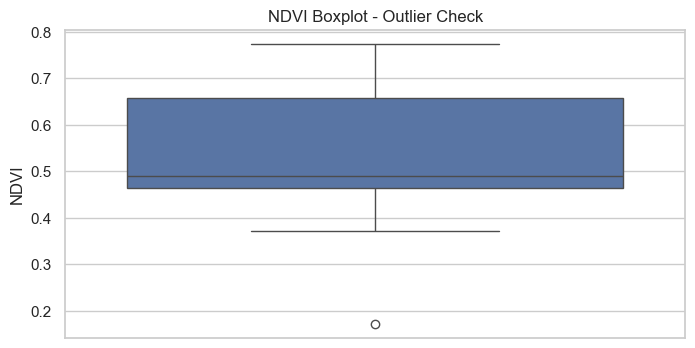

In [17]:
plt.figure(figsize=(8,4))
sns.boxplot(y=df['NDVI'])
plt.title("NDVI Boxplot - Outlier Check")
plt.show()

In [18]:
features = ['rainfall','wet_days','temperature_T2M','irradiance_SW_DWN','total_workforce','female_workforceRatio','yield_lag_1','yield_lag_2','yield_lag_3','rainfall_lag_1','sin_month','cos_month','NDVI']    #added sin_month and cos_month to features-15.02.2026

target = ['yield']
X=df[features]
Y=df[target]

In [19]:
split_idx=int(len(df)*0.8)
x_train = X.iloc[:split_idx]
y_train = Y.iloc[:split_idx]

x_test = X.iloc[split_idx:]
y_test = Y.iloc[split_idx:]


In [20]:
#TRAINING CATBOOST MODEL

cat_model = CatBoostRegressor(iterations = 1000,
                              learning_rate = 0.05,
                              depth = 6,
                              loss_function = 'RMSE',
                              eval_metric = 'RMSE',
                              random_seed = 42,
                              verbose = 100)

#fit model
cat_model.fit(x_train, y_train,eval_set = (x_test, y_test),early_stopping_rounds = 50)

0:	learn: 13891.5018093	test: 11714.8307960	best: 11714.8307960 (0)	total: 185ms	remaining: 3m 4s
100:	learn: 4943.8913796	test: 10107.7401093	best: 10102.8120735 (88)	total: 284ms	remaining: 2.52s
200:	learn: 2066.4527060	test: 10083.8997509	best: 9932.9324604 (163)	total: 372ms	remaining: 1.48s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 9932.93246
bestIteration = 163

Shrink model to first 164 iterations.


In [21]:
y_pred_cat = cat_model.predict(x_test)

In [22]:
mse = mean_squared_error(y_test, y_pred_cat)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_cat)
r2 = r2_score(y_test, y_pred_cat)

print("CatBoost Yield Prediction Performance")
print(f"RMSE: {rmse:.2f}")
print(f"MAE : {mae:.2f}")
print(f"R²  : {r2:.3f}")


CatBoost Yield Prediction Performance
RMSE: 9932.93
MAE : 8181.83
R²  : -0.104


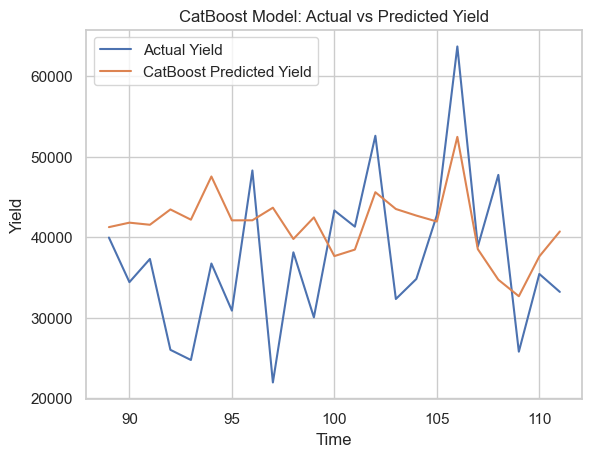

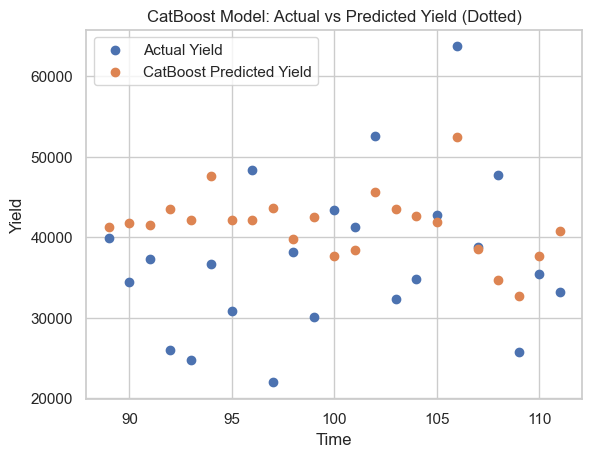

In [23]:
#line plot
plt.figure()

plt.plot(y_test.index, y_test.values, label="Actual Yield")
plt.plot(y_test.index, y_pred_cat, label="CatBoost Predicted Yield")

plt.legend()
plt.title("CatBoost Model: Actual vs Predicted Yield")
plt.xlabel("Time")
plt.ylabel("Yield")

plt.show()

#scatter plot
plt.figure()

plt.scatter(y_test.index, y_test.values,
            label="Actual Yield")

plt.scatter(y_test.index, y_pred_cat,
            label="CatBoost Predicted Yield")

plt.legend()
plt.title("CatBoost Model: Actual vs Predicted Yield (Dotted)")
plt.xlabel("Time")
plt.ylabel("Yield")

plt.show()